# 💎 Diamonds Dataset – Exploratory Data Analysis (EDA)
### Data Science with Python Internship – Task 3 (New Dataset)
---
**Dataset:** Diamonds (~54,000 records) — one of the most popular datasets for EDA practice  
**Goal:** Analyze what factors drive diamond prices using cleaning, groupby insights, and rich visualizations.

**Key Questions We'll Answer:**
- How does **carat** affect price?
- Which **cut, color, clarity** grades are most valuable?
- What are the **correlations** between numeric features?
- How does **price vary across quality tiers**?


## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans'
})

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 2. 📥 Load the Dataset

In [2]:
df = pd.read_csv("diamonds.csv")

print(f"📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {df.columns.tolist()}")
df.head(8)


📐 Shape: 53,940 rows × 10 columns

📋 Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.43,Premium,E,SI2,60.5,56.0,880,1.83,1.85,1.12
1,2.02,Ideal,F,VS2,64.1,57.0,11849,9.53,9.44,6.08
2,1.35,Ideal,E,VS1,62.1,57.0,7300,5.57,5.55,3.46
3,0.56,Premium,H,VVS2,60.8,55.0,1429,2.36,2.36,1.44
4,0.42,Very Good,J,VS2,62.6,56.0,607,1.75,1.76,1.10
5,2.48,Very Good,D,VS2,60.9,59.0,18823,11.39,11.51,6.97
6,0.42,Good,E,VS2,62.1,56.0,809,1.73,1.72,1.07
7,0.26,Ideal,E,SI1,61.1,59.0,374,1.01,1.03,0.63


## 3. 🔍 Initial Exploration

In [3]:
print("=== Data Types & Non-Null Counts ===")
df.info()


=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [4]:
print("=== Statistical Summary ===")
df.describe().round(2)


=== Statistical Summary ===


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.70,61.71,57.49,2324.73,3.01,3.01,1.86
std,0.50,1.05,2.23,2995.40,2.15,2.15,1.33
min,0.20,57.00,48.00,326.00,0.66,0.66,0.42
25%,0.34,61.00,56.00,541.00,1.47,1.47,0.91
50%,0.55,61.70,57.00,1196.00,2.35,2.35,1.45
75%,0.89,62.40,59.00,2778.00,3.83,3.83,2.37
max,5.01,66.00,67.00,18823.00,23.80,23.62,14.81


In [5]:
# Categorical column distributions
print("✂️  Cut categories:    ", df['cut'].unique().tolist())
print("🎨 Color categories:  ", df['color'].unique().tolist())
print("🔬 Clarity categories:", df['clarity'].unique().tolist())

print("\n--- Value Counts ---")
for col in ['cut', 'color', 'clarity']:
    print(f"\n{col}:")
    print(df[col].value_counts())


✂️  Cut categories:     ['Premium', 'Ideal', 'Very Good', 'Good', 'Fair']
🎨 Color categories:   ['E', 'F', 'H', 'J', 'D', 'G', 'I']
🔬 Clarity categories: ['SI2', 'VS2', 'VS1', 'VVS2', 'SI1', 'IF', 'I1', 'VVS1']

--- Value Counts ---

cut:
cut
Ideal        20446
Premium      13983
Very Good    11937
Good          4888
Fair          2686
Name: count, dtype: int64

color:
color
G    10335
E     8695
H     8108
F     7432
I     7198
D     6411
J     5761
Name: count, dtype: int64

clarity:


clarity
SI1     12816
VS2     10278
SI2      9208
VS1      8034
VVS2     6568
VVS1     3772
IF       2217
I1       1047
Name: count, dtype: int64


In [6]:
# Missing value check
missing = df.isnull().sum()
print("=== Missing Values ===")
if missing.sum() == 0:
    print("✅ No missing values found! Dataset is clean.")
else:
    print(missing[missing > 0])


=== Missing Values ===
✅ No missing values found! Dataset is clean.


## 4. 🧹 Data Cleaning
Even though the diamonds dataset is relatively clean, we'll apply best practices:
- Check and remove **zero-value dimensions** (x, y, z = 0 are physical impossibilities)
- Remove **outliers** in depth and table
- Create **ordered categories** for cut, color, clarity


In [7]:
# Remove physically impossible entries (x, y, or z = 0)
before = len(df)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"✅ Removed {before - len(df)} rows with zero dimensions")

# Remove extreme outliers in depth and table
df = df[(df['depth'] > 50) & (df['depth'] < 75)]
df = df[(df['table'] > 45) & (df['table'] < 80)]
print(f"✅ Removed extreme outliers in depth/table")

# Define ordered categorical types
cut_order    = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order  = ['J', 'I', 'H', 'G', 'F', 'E', 'D']   # D = best, J = worst
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut']     = pd.Categorical(df['cut'],     categories=cut_order,     ordered=True)
df['color']   = pd.Categorical(df['color'],   categories=color_order,   ordered=True)
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)

print(f"\n✅ Clean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)


✅ Removed 0 rows with zero dimensions
✅ Removed extreme outliers in depth/table



✅ Clean dataset shape: 53,940 rows × 10 columns


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.43,Premium,E,SI2,60.5,56.0,880,1.83,1.85,1.12
1,2.02,Ideal,F,VS2,64.1,57.0,11849,9.53,9.44,6.08
2,1.35,Ideal,E,VS1,62.1,57.0,7300,5.57,5.55,3.46
3,0.56,Premium,H,VVS2,60.8,55.0,1429,2.36,2.36,1.44
4,0.42,Very Good,J,VS2,62.6,56.0,607,1.75,1.76,1.10


## 5. ⚙️ Feature Engineering

In [8]:
# Price per carat
df['price_per_carat'] = (df['price'] / df['carat']).round(0)

# Volume approximation
df['volume'] = (df['x'] * df['y'] * df['z']).round(2)

# Price tier
df['price_tier'] = pd.cut(
    df['price'],
    bins=[0, 1000, 3000, 7000, 20000],
    labels=['Budget (<$1K)', 'Mid ($1K–$3K)', 'Premium ($3K–$7K)', 'Luxury (>$7K)']
)

# Carat group
df['carat_group'] = pd.cut(
    df['carat'],
    bins=[0, 0.5, 1.0, 1.5, 2.0, 6.0],
    labels=['<0.5ct', '0.5–1ct', '1–1.5ct', '1.5–2ct', '>2ct']
)

print("✅ New features created:")
print(f"  price_per_carat — range: ${df['price_per_carat'].min():,.0f} to ${df['price_per_carat'].max():,.0f}")
print(f"  volume          — range: {df['volume'].min():.2f} to {df['volume'].max():.2f} mm³")
print(f"  price_tier      — {df['price_tier'].value_counts().to_dict()}")
print(f"  carat_group     — {df['carat_group'].value_counts().to_dict()}")


✅ New features created:
  price_per_carat — range: $950 to $8,605
  volume          — range: 0.18 to 8325.53 mm³
  price_tier      — {'Budget (<$1K)': 23869, 'Mid ($1K–$3K)': 17659, 'Premium ($3K–$7K)': 8633, 'Luxury (>$7K)': 3779}
  carat_group     — {'<0.5ct': 24634, '0.5–1ct': 18536, '1–1.5ct': 6796, '1.5–2ct': 2544, '>2ct': 1430}


## 6. 📊 GroupBy Analysis

### Q1: Average Price by Cut

In [9]:
price_by_cut = df.groupby('cut', observed=True)['price'].agg(
    Count='count', Mean_Price='mean', Median_Price='median', Max_Price='max'
).round(0)
print(price_by_cut.sort_values('Mean_Price', ascending=False))
print("\n💡 Note: 'Fair' cut often commands higher prices due to larger carats!")


           Count  Mean_Price  Median_Price  Max_Price
cut                                                  
Ideal      20446      2474.0        1277.0      18823
Premium    13983      2346.0        1209.0      18823
Very Good  11937      2257.0        1174.0      18823
Good        4888      2065.0        1058.0      18823
Fair        2686      1850.0         940.0      18823

💡 Note: 'Fair' cut often commands higher prices due to larger carats!


### Q2: Average Price by Color

In [10]:
price_by_color = df.groupby('color', observed=True)['price'].agg(
    Count='count', Mean_Price='mean', Median_Price='median'
).round(0)
print(price_by_color)


       Count  Mean_Price  Median_Price
color                                 
J       5761      2043.0        1020.0
I       7198      2090.0        1098.0
H       8108      2233.0        1177.0
G      10335      2332.0        1192.0
F       7432      2373.0        1232.0
E       8695      2543.0        1316.0
D       6411      2594.0        1343.0


### Q3: Average Price by Clarity

In [11]:
price_by_clarity = df.groupby('clarity', observed=True)['price'].agg(
    Count='count', Mean_Price='mean', Median_Price='median'
).round(0)
print(price_by_clarity)


         Count  Mean_Price  Median_Price
clarity                                 
I1        1047      1885.0         973.0
SI2       9208      2121.0        1070.0
SI1      12816      2214.0        1152.0
VS2      10278      2349.0        1200.0
VS1       8034      2382.0        1236.0
VVS2      6568      2513.0        1302.0
VVS1      3772      2530.0        1340.0
IF        2217      2796.0        1474.0


### Q4: Price per Carat by Cut & Color (Pivot Table)

In [12]:
pivot = df.pivot_table(
    values='price_per_carat',
    index='cut',
    columns='color',
    aggfunc='mean'
).round(0)
print(pivot)


color           J       I       H       G       F       E       D
cut                                                              
Fair       1819.0  1849.0  1976.0  2005.0  2097.0  2191.0  2313.0
Good       1847.0  2034.0  2170.0  2304.0  2349.0  2435.0  2527.0
Very Good  2172.0  2272.0  2394.0  2457.0  2543.0  2645.0  2772.0
Premium    2287.0  2346.0  2461.0  2601.0  2652.0  2782.0  2833.0
Ideal      2340.0  2448.0  2586.0  2708.0  2795.0  2903.0  2982.0


## 7. 📈 Visualizations

### Viz 1: Price Distribution

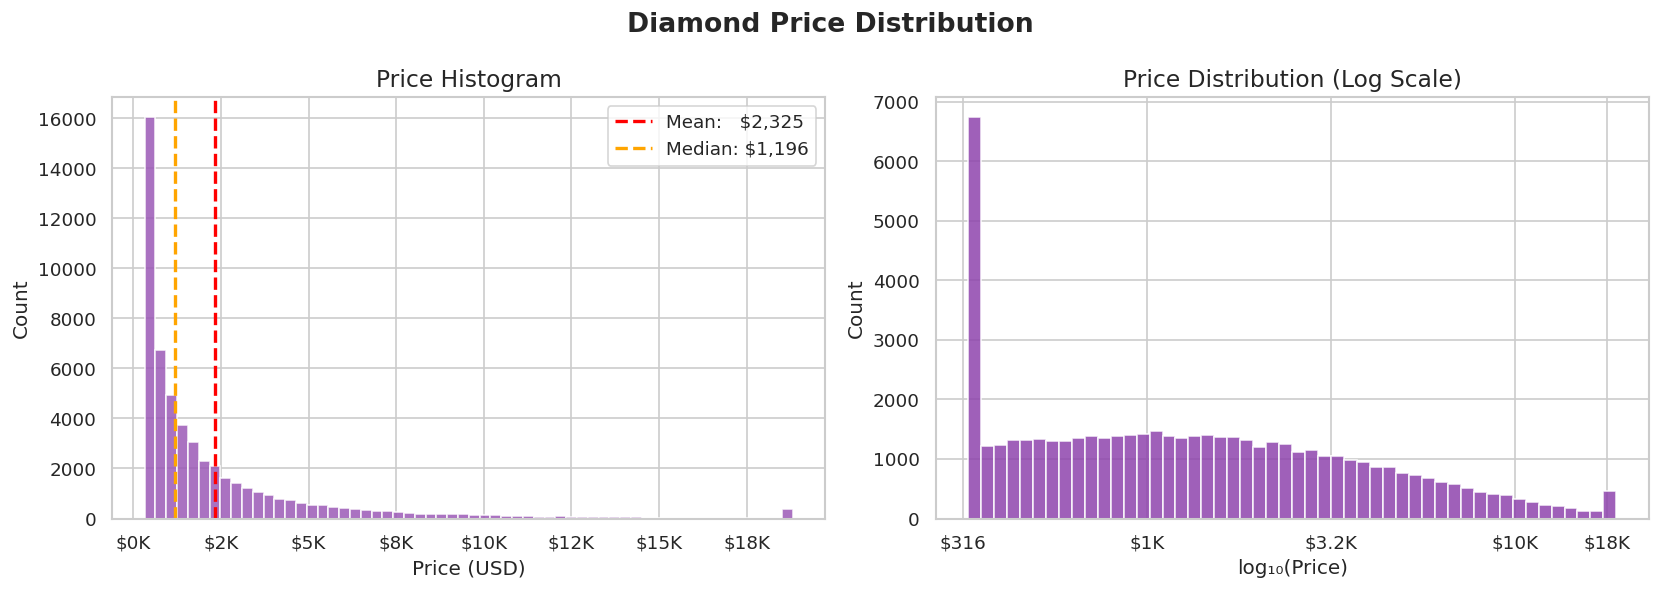


📌 Insight: Price is right-skewed. Most diamonds cost under $3,000, with a long tail of luxury stones.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diamond Price Distribution', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df['price'], bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(df['price'].mean(),   color='red',    linestyle='--', lw=2, label=f"Mean:   ${df['price'].mean():,.0f}")
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', lw=2, label=f"Median: ${df['price'].median():,.0f}")
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Histogram')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Log-scale for better shape visibility
axes[1].hist(np.log10(df['price']), bins=50, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log₁₀(Price)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xticks([2.5, 3, 3.5, 4, 4.25])
axes[1].set_xticklabels(['$316', '$1K', '$3.2K', '$10K', '$18K'])

plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Insight: Price is right-skewed. Most diamonds cost under $3,000, with a long tail of luxury stones.")


### Viz 2: Carat vs Price (The Key Relationship)

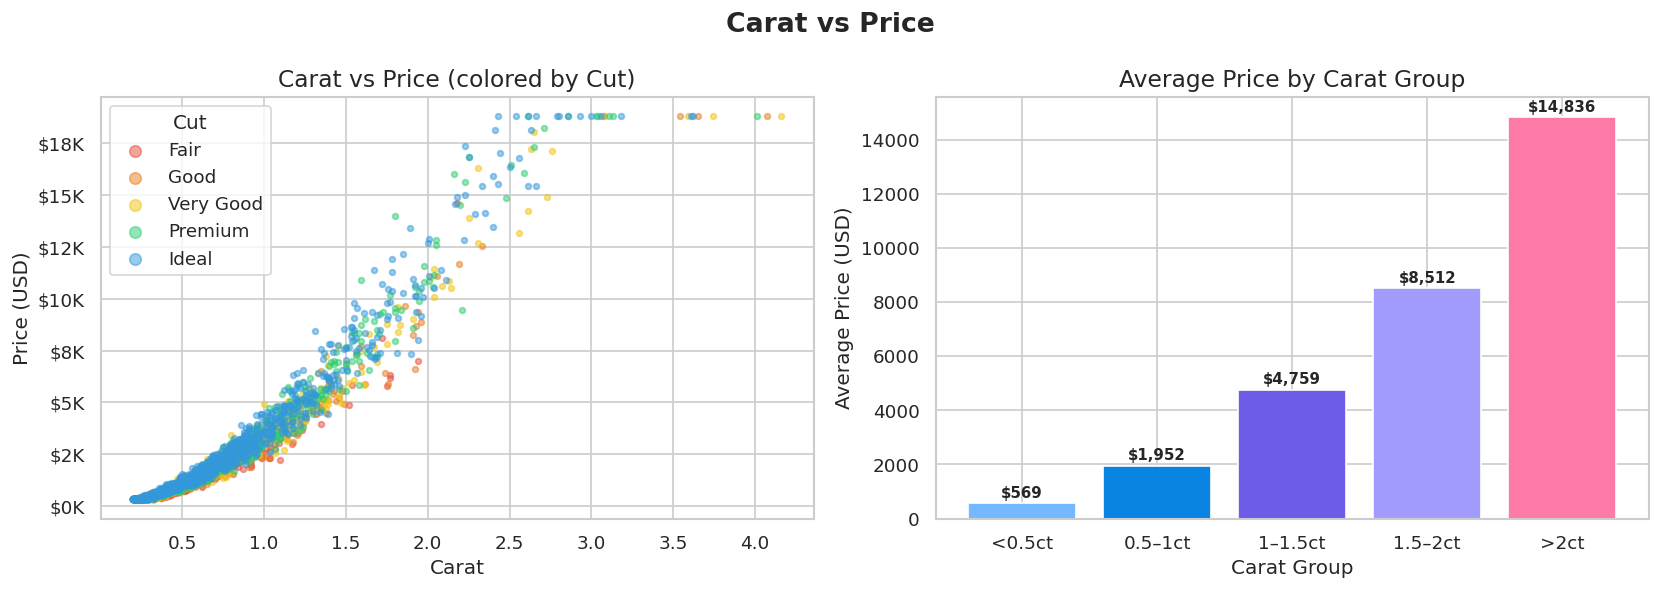


📌 Insight: Carat is the strongest price driver. Price rises exponentially, not linearly, with carat.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Carat vs Price', fontsize=16, fontweight='bold')

# Scatter colored by cut
cut_colors = {'Fair': '#e74c3c', 'Good': '#e67e22', 'Very Good': '#f1c40f', 'Premium': '#2ecc71', 'Ideal': '#3498db'}
sample = df.sample(3000, random_state=42)
for cut in cut_order:
    subset = sample[sample['cut'] == cut]
    axes[0].scatter(subset['carat'], subset['price'], c=cut_colors[cut],
                    label=cut, alpha=0.5, s=12)
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Carat vs Price (colored by Cut)')
axes[0].legend(title='Cut', markerscale=2)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Carat group average price
carat_avg = df.groupby('carat_group', observed=True)['price'].mean()
bars = axes[1].bar(carat_avg.index, carat_avg.values,
                   color=['#74b9ff','#0984e3','#6c5ce7','#a29bfe','#fd79a8'], edgecolor='white')
axes[1].set_xlabel('Carat Group')
axes[1].set_ylabel('Average Price (USD)')
axes[1].set_title('Average Price by Carat Group')
for bar, val in zip(bars, carat_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('carat_vs_price.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Insight: Carat is the strongest price driver. Price rises exponentially, not linearly, with carat.")


### Viz 3: Price by Cut, Color & Clarity

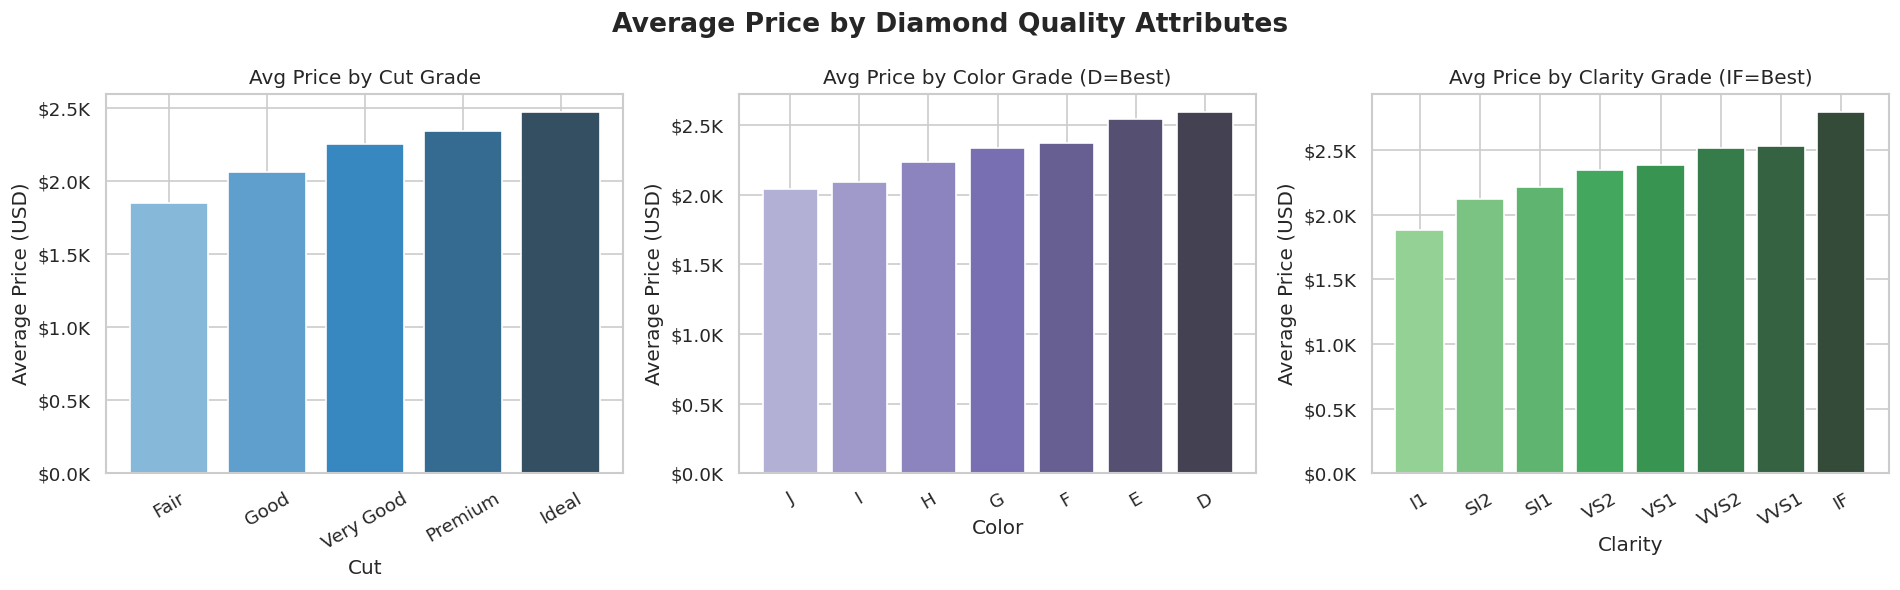


📌 Insight: Paradoxically, 'Fair' cut and lower color/clarity can be more expensive — they often come in larger carats!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Average Price by Diamond Quality Attributes', fontsize=16, fontweight='bold')

for ax, col, order, palette, title in zip(
    axes,
    ['cut', 'color', 'clarity'],
    [cut_order, color_order, clarity_order],
    ['Blues_d', 'Purples_d', 'Greens_d'],
    ['Cut Grade', 'Color Grade (D=Best)', 'Clarity Grade (IF=Best)']
):
    avg = df.groupby(col, observed=True)['price'].mean().reindex(order)
    bars = ax.bar(avg.index, avg.values, color=sns.color_palette(palette, len(order)), edgecolor='white')
    ax.set_title(f'Avg Price by {title}', fontsize=12)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Average Price (USD)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}K'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('price_by_quality.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Insight: Paradoxically, 'Fair' cut and lower color/clarity can be more expensive — they often come in larger carats!")


### Viz 4: Correlation Heatmap

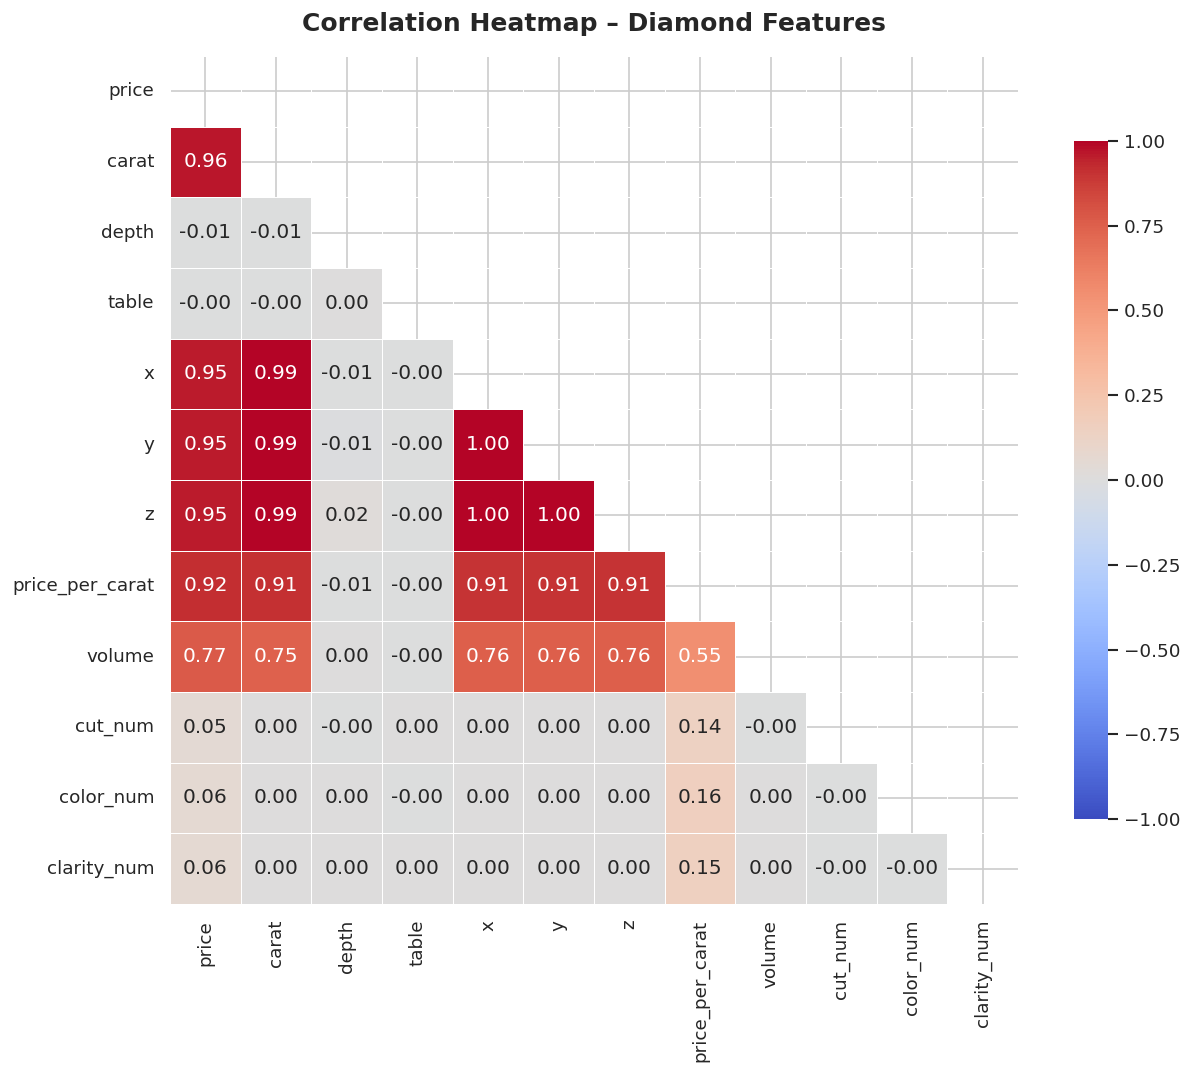


📌 Insight: carat, x, y, z, and volume are all highly correlated with price (>0.85). depth and table have weak correlations.


In [16]:
# Encode ordinals for correlation
df_enc = df.copy()
df_enc['cut_num']     = df_enc['cut'].cat.codes
df_enc['color_num']   = df_enc['color'].cat.codes
df_enc['clarity_num'] = df_enc['clarity'].cat.codes

corr_cols = ['price', 'carat', 'depth', 'table', 'x', 'y', 'z',
             'price_per_carat', 'volume', 'cut_num', 'color_num', 'clarity_num']
corr = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap – Diamond Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Insight: carat, x, y, z, and volume are all highly correlated with price (>0.85). depth and table have weak correlations.")


### Viz 5: Price Distribution by Cut & Clarity (Box Plots)

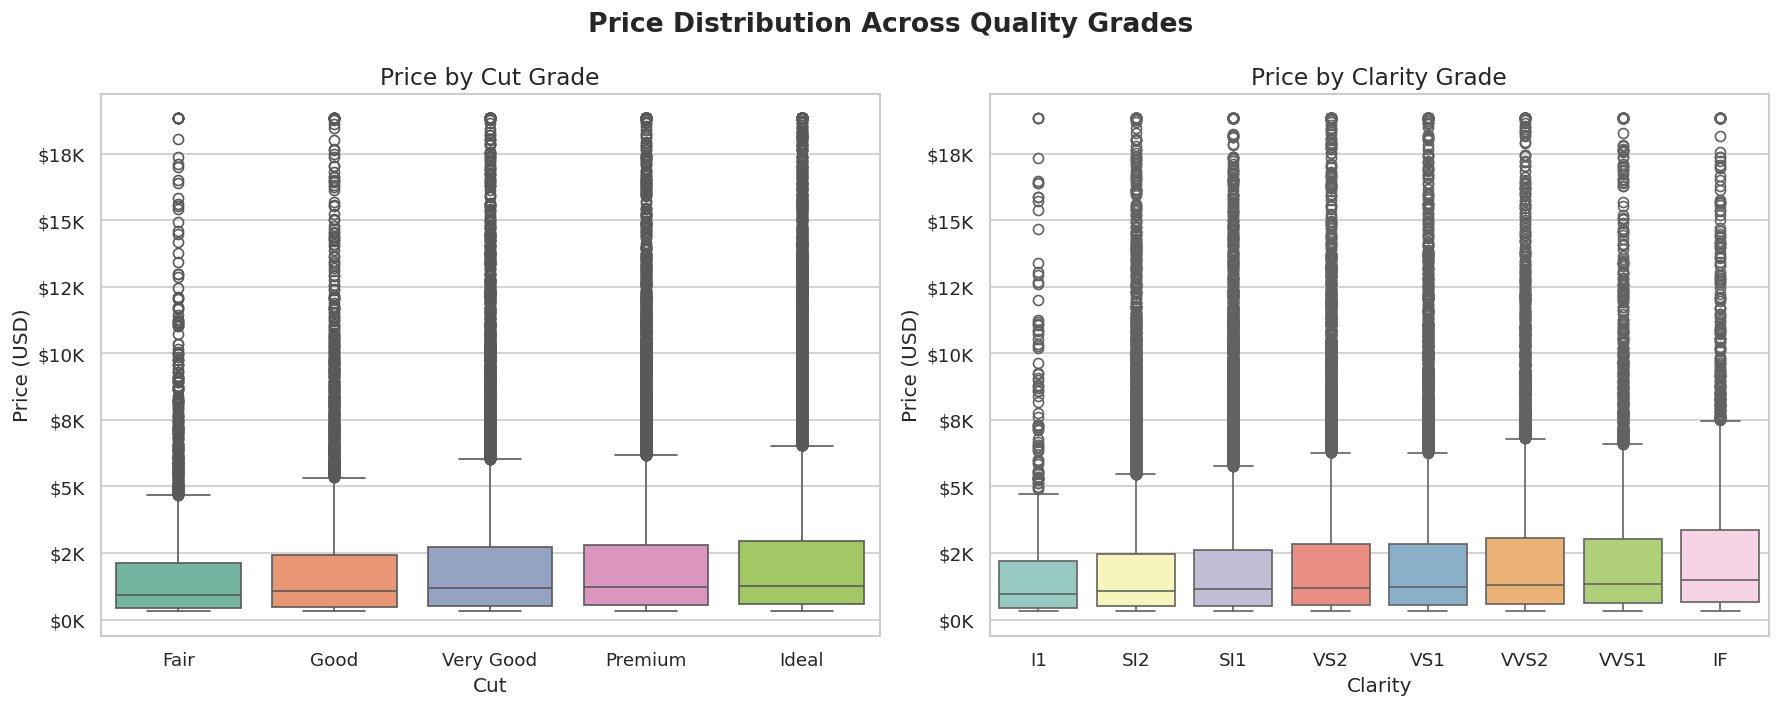


📌 Insight: Wide spread in all categories — carat weight within each grade explains the high variance.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Price Distribution Across Quality Grades', fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='cut', y='price', order=cut_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Price by Cut Grade')
axes[0].set_xlabel('Cut')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

sns.boxplot(data=df, x='clarity', y='price', order=clarity_order,
            palette='Set3', ax=axes[1])
axes[1].set_title('Price by Clarity Grade')
axes[1].set_xlabel('Clarity')
axes[1].set_ylabel('Price (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Insight: Wide spread in all categories — carat weight within each grade explains the high variance.")


### Viz 6: Price Tiers & Cut Distribution

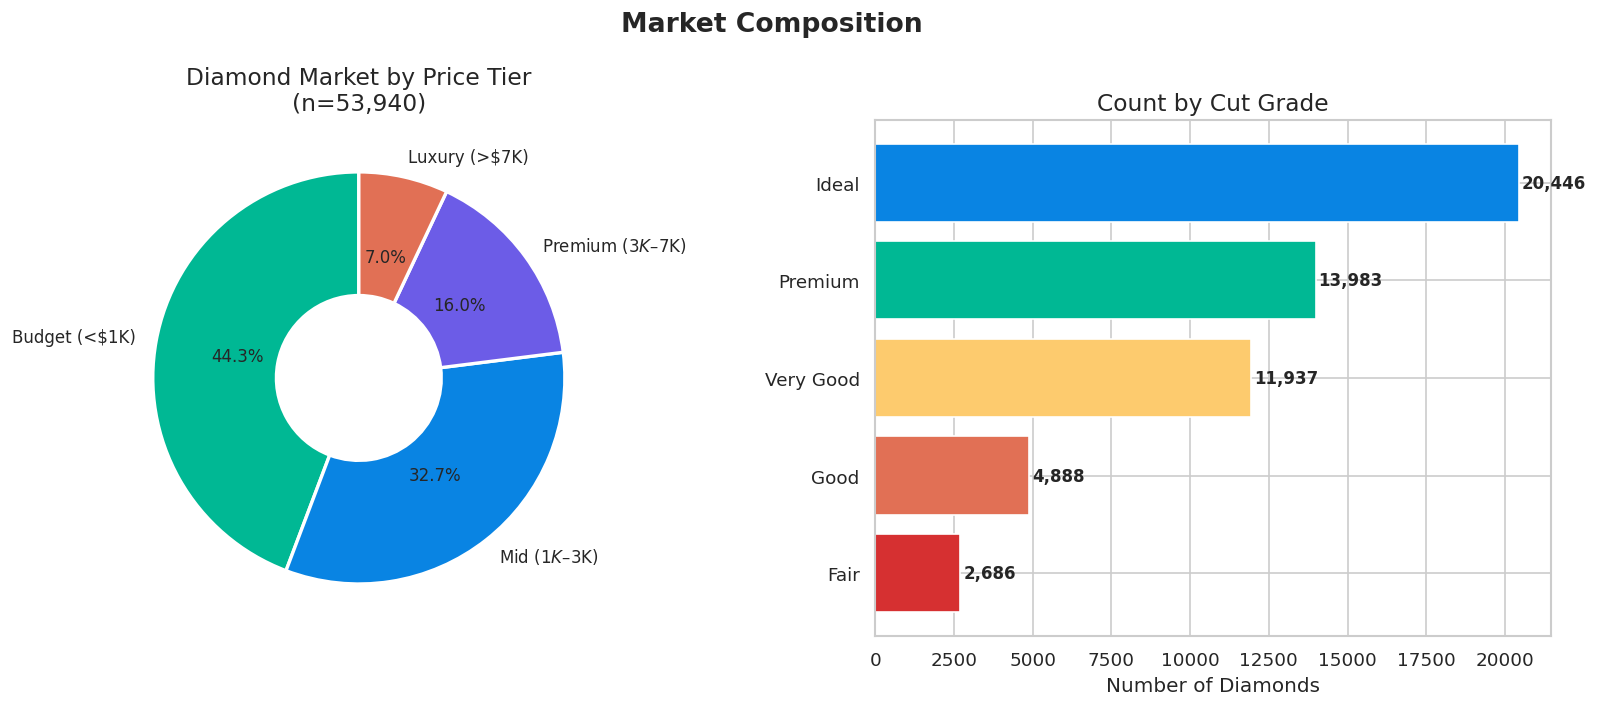


📌 Insight: ~60% of diamonds fall under $3,000. 'Ideal' is the most common cut grade in the market.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Market Composition', fontsize=16, fontweight='bold')

# Price tier donut
tier_counts = df['price_tier'].value_counts()
colors_t = ['#00b894', '#0984e3', '#6c5ce7', '#e17055']
wedges, texts, autotexts = axes[0].pie(
    tier_counts.values, labels=tier_counts.index,
    autopct='%1.1f%%', colors=colors_t, startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
axes[0].set_title(f'Diamond Market by Price Tier\n(n={len(df):,})')

# Cut count bar
cut_counts = df['cut'].value_counts().reindex(cut_order)
bars = axes[1].barh(cut_order, cut_counts.values,
                    color=['#d63031','#e17055','#fdcb6e','#00b894','#0984e3'], edgecolor='white')
axes[1].set_xlabel('Number of Diamonds')
axes[1].set_title('Count by Cut Grade')
for bar, val in zip(bars, cut_counts.values):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('market_composition.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Insight: ~60% of diamonds fall under $3,000. 'Ideal' is the most common cut grade in the market.")


## 8. 📝 Key Findings & Conclusions

| Finding | Detail |
|---|---|
| **Strongest Price Driver** | **Carat** — price rises exponentially with weight |
| **Cut Paradox** | 'Fair' cut can be pricier than 'Ideal' — often due to larger carat |
| **Color Paradox** | Lower color grades (I, J) appear expensive due to carat size confounding |
| **Clarity** | Higher clarity (VVS1, IF) commands premium price per carat |
| **Correlations** | carat, x, y, z, volume all correlate >0.85 with price |
| **Market Split** | ~60% of diamonds under $3K; only ~15% are Luxury tier (>$7K) |
| **Ideal Cut** | Most popular cut (~38% of market) — best balance of brilliance & value |

### 🔑 EDA Workflow Recap
1. **Load** → Read CSV, inspect shape, dtypes, value counts
2. **Explore** → Statistical summary, categorical distributions, missing check
3. **Clean** → Remove impossible zeros, filter outliers, set ordered categories
4. **Engineer** → price_per_carat, volume, price_tier, carat_group
5. **Analyze** → groupby to find avg prices by cut/color/clarity, pivot tables
6. **Visualize** → Histograms, scatter, bar plots, box plots, heatmap, donut

> *"A diamond's value isn't just about its grade — context (carat size) tells the real story. Same with data."*
